In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import MinMaxScaler
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import LSTM, Dense, Dropout
from tensorflow.keras.callbacks import EarlyStopping
from sklearn.metrics import mean_absolute_error, mean_squared_error
from pandas.plotting import autocorrelation_plot

In [2]:
dataset_path = "data_hourly final.csv"

df = pd.read_csv(dataset_path)
print("Device ID:", df["device_id"].unique())
df.head()


Device ID: ['USGC00']


,data_id,device_id,datetime,voltage,current,power,energy,frequency,pf,energy_hour
0,1,USGC00,2025-08-11 17:00:00,233.020,2.43758,543.043,55.654,50.0000,0.953167,0.352
1,2,USGC00,2025-08-11 18:00:00,234.557,2.54540,582.805,56.045,50.0000,0.973000,0.391
2,3,USGC00,2025-08-11 19:00:00,239.353,1.19923,250.752,56.445,50.0000,0.871667,0.400
3,4,USGC00,2025-08-11 20:00:00,240.775,1.03432,209.535,56.669,49.9883,0.840167,0.224
4,5,USGC00,2025-08-11 21:00:00,237.303,1.32697,283.777,56.894,50.0000,0.900667,0.225


In [3]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 3762 entries, 0 to 3761
Data columns (total 10 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   data_id      3762 non-null   int64  
 1   device_id    3762 non-null   object 
 2   datetime     3762 non-null   object 
 3   voltage      3762 non-null   float64
 4   current      3762 non-null   float64
 5   power        3762 non-null   float64
 6   energy       3762 non-null   float64
 7   frequency    3762 non-null   float64
 8   pf           3762 non-null   float64
 9   energy_hour  3762 non-null   float64
dtypes: float64(7), int64(1), object(2)
memory usage: 294.0+ KB


In [4]:
df.isna().sum()

data_id        0
device_id      0
datetime       0
voltage        0
current        0
power          0
energy         0
frequency      0
pf             0
energy_hour    0
dtype: int64

In [5]:
df.drop(columns=["data_id"], inplace=True)
df.drop(columns=["device_id"], inplace=True)
df["datetime"] = pd.to_datetime(df["datetime"])
df = df.sort_values("datetime")
df = df.set_index("datetime")

df.info()

<class 'pandas.core.frame.DataFrame'>
DatetimeIndex: 3762 entries, 2025-08-11 17:00:00 to 2026-01-16 14:00:00
Data columns (total 7 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   voltage      3762 non-null   float64
 1   current      3762 non-null   float64
 2   power        3762 non-null   float64
 3   energy       3762 non-null   float64
 4   frequency    3762 non-null   float64
 5   pf           3762 non-null   float64
 6   energy_hour  3762 non-null   float64
dtypes: float64(7)
memory usage: 235.1 KB


In [6]:
df.index = df.index.floor('H')

print("Jumlah data duplikat:", df.index.duplicated().sum())
df[df.index.duplicated(keep=False)]

Jumlah data duplikat: 2


C:\Users\hakimfrh\AppData\Local\Temp\ipykernel_20148\287894102.py:1: FutureWarning: 'H' is deprecated and will be removed in a future version, please use 'h' instead.
  df.index = df.index.floor('H')


,voltage,current,power,energy,frequency,pf,energy_hour
datetime,,,,,,,
2025-08-24 08:00:00,237.762,0.717983,162.718,111.848,50.0000,0.950000,0.121
2025-08-24 08:00:00,238.469,0.547775,118.228,111.968,49.9941,0.886921,0.121
2025-08-24 11:00:00,238.098,0.726850,162.930,112.288,50.0000,0.936333,0.173
2025-08-24 11:00:00,238.150,0.595139,129.571,112.419,49.9842,0.901140,0.173


In [7]:
df = df[~df.index.duplicated()]
print("Jumlah data duplikat:", df.index.duplicated().sum())
df[df.index.duplicated(keep=False)]

Jumlah data duplikat: 0


,voltage,current,power,energy,frequency,pf,energy_hour
datetime,,,,,,,


array([<Axes: xlabel='datetime'>, <Axes: xlabel='datetime'>,
       <Axes: xlabel='datetime'>, <Axes: xlabel='datetime'>,
       <Axes: xlabel='datetime'>, <Axes: xlabel='datetime'>,
       <Axes: xlabel='datetime'>], dtype=object)

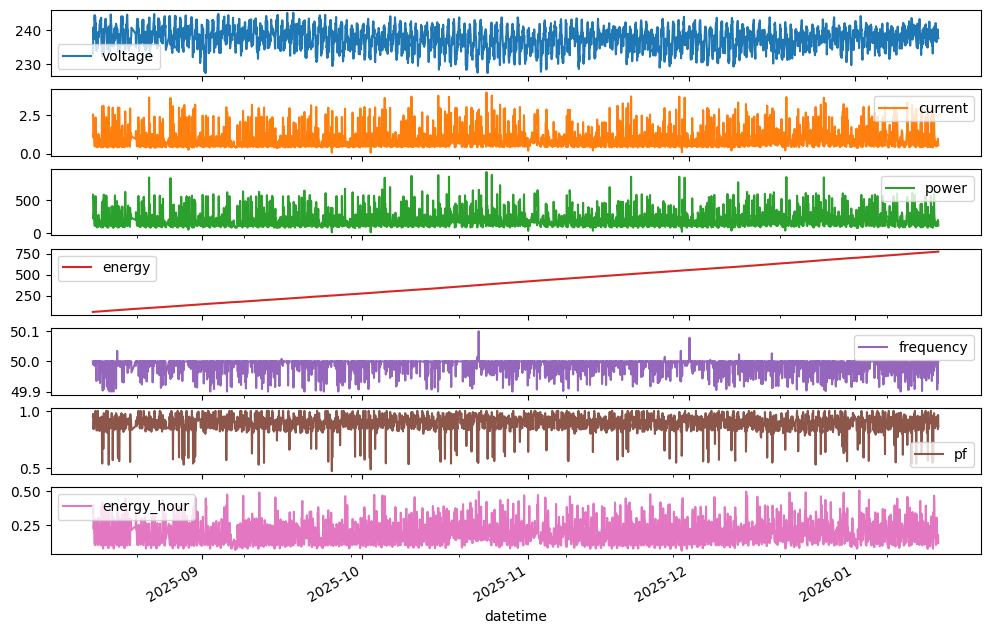

In [8]:
df.plot(subplots=True, figsize=(12,8))

In [9]:
df.drop(columns=["voltage"], inplace=True)
df.drop(columns=["current"], inplace=True)
df.drop(columns=["power"], inplace=True)
df.drop(columns=["energy"], inplace=True)
df.drop(columns=["frequency"], inplace=True)
df.drop(columns=["pf"], inplace=True)

In [10]:
df = df[df["energy_hour"] >= 0]

<class 'pandas.core.frame.DataFrame'>
DatetimeIndex: 3760 entries, 2025-08-11 17:00:00 to 2026-01-16 14:00:00
Data columns (total 1 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   energy_hour  3760 non-null   float64
dtypes: float64(1)
memory usage: 187.8 KB


array([<Axes: xlabel='datetime'>], dtype=object)

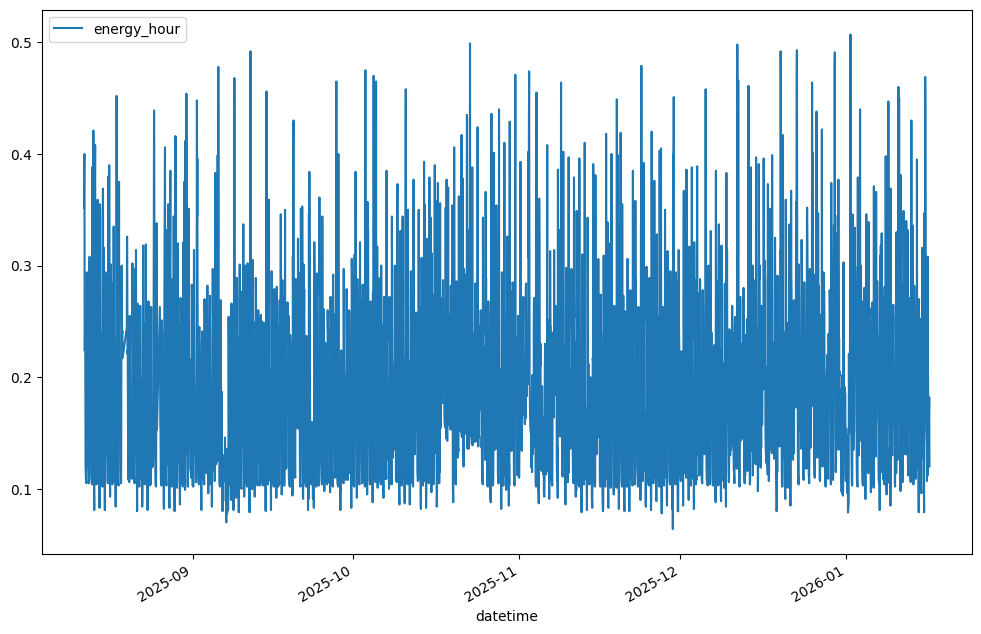

In [11]:
df.info()
df.plot(subplots=True, figsize=(12,8))

In [12]:
full_range = pd.date_range(start=df.index.min(),
                           end=df.index.max(),
                           freq="H")

missing_time = full_range.difference(df.index)
print("Jumlah jam hilang:", len(missing_time))
print(missing_time)

Jumlah jam hilang: 30
DatetimeIndex(['2025-08-18 23:00:00', '2025-08-19 00:00:00',
               '2025-08-19 01:00:00', '2025-08-19 02:00:00',
               '2025-08-19 03:00:00', '2025-08-19 04:00:00',
               '2025-08-19 05:00:00', '2025-08-19 06:00:00',
               '2025-08-19 07:00:00', '2025-08-19 08:00:00',
               '2025-08-19 09:00:00', '2025-08-19 10:00:00',
               '2025-08-19 11:00:00', '2025-08-19 12:00:00',
               '2025-08-19 13:00:00', '2025-08-19 14:00:00',
               '2025-08-19 15:00:00', '2025-08-19 16:00:00',
               '2025-08-25 09:00:00', '2025-08-25 10:00:00',
               '2025-08-25 11:00:00', '2025-08-25 12:00:00',
               '2025-08-25 13:00:00', '2025-08-25 14:00:00',
               '2025-08-25 15:00:00', '2025-08-25 16:00:00',
               '2025-08-25 17:00:00', '2025-08-25 18:00:00',
               '2025-08-25 19:00:00', '2025-08-25 20:00:00'],
              dtype='datetime64[ns]', freq=None)


C:\Users\hakimfrh\AppData\Local\Temp\ipykernel_20148\3867691930.py:1: FutureWarning: 'H' is deprecated and will be removed in a future version, please use 'h' instead.
  full_range = pd.date_range(start=df.index.min(),


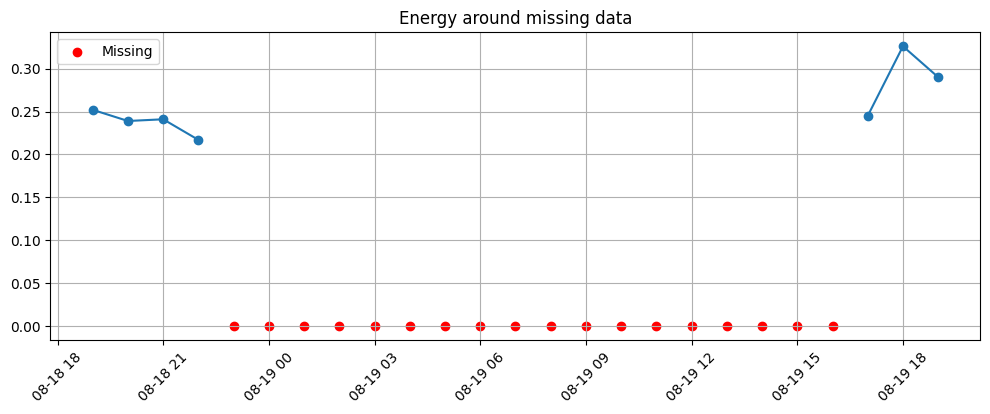

In [13]:
start = "2025-08-18 19:00:00"
end   = "2025-08-19 19:00:00"

full_range = pd.date_range(start=start, end=end, freq="h")
df_zoom = df.reindex(full_range)
df_zoom.head(10)
import matplotlib.pyplot as plt



plt.figure(figsize=(12,4))
plt.plot(df_zoom.index, df_zoom["energy_hour"], marker="o")
plt.scatter(df_zoom.index[df_zoom["energy_hour"].isna()],
            [0]*df_zoom["energy_hour"].isna().sum(),
            color="red", label="Missing")
plt.legend()
plt.title("Energy around missing data")
plt.xticks(rotation=45)
plt.grid()
plt.show()


In [14]:
# def smart_fill(df, col, data_limit=2):
#     df = df.copy()

#     for t in df[df[col].isna()].index:
#         values = []

#         # 1. Tetangga jam dekat
#         for h in [-1, 1]:
#             if t + pd.Timedelta(hours=h) in df.index:
#                 val = df.loc[t + pd.Timedelta(hours=h), col]
#                 if not pd.isna(val):
#                     values.append(val)

#         # 2. Hari sebelum & sesudah
#         for d in [-1, 1]:
#             time_check = t + pd.Timedelta(days=d)
#             if time_check in df.index:
#                 val = df.loc[time_check, col]
#                 if not pd.isna(val):
#                     values.append(val)

#         # 3. Minggu sekitar (sesuai data_limit)
#         for w in range(1, data_limit+1):
#             for sign in [-1, 1]:
#                 time_check = t + pd.Timedelta(weeks=w*sign)
#                 if time_check in df.index:
#                     val = df.loc[time_check, col]
#                     if not pd.isna(val):
#                         values.append(val)

#         # Isi pakai median
#         if values:
#             df.loc[t, col] = np.median(values)

#     return df


def smart_fill(df, col, data_limit=2, verbose=True):
    df = df.copy()

    missing_times = df[df[col].isna()].index
    print(f"\nTotal missing value di kolom '{col}':", len(missing_times))

    for t in missing_times:
        values = []
        if verbose:
            print("\n==============================")
            print(f"Isi nilai untuk waktu: {t}")

        # 1️⃣ Tetangga jam dekat
        for h in [-1, 1]:
            check_time = t + pd.Timedelta(hours=h)
            if check_time in df.index:
                val = df.loc[check_time, col]
                if not pd.isna(val):
                    values.append(val)
                    if verbose:
                        print(f"  ✔ Tetangga jam ({h:+}h): {check_time} → {val}")
                else:
                    if verbose:
                        print(f"  ✖ Tetangga jam ({h:+}h): {check_time} ada tapi NaN")
            else:
                if verbose:
                    print(f"  - Tetangga jam ({h:+}h): {check_time} tidak ada di index")

        # 2️⃣ Hari sebelum & sesudah
        for d in [-1, 1]:
            check_time = t + pd.Timedelta(days=d)
            if check_time in df.index:
                val = df.loc[check_time, col]
                if not pd.isna(val):
                    values.append(val)
                    if verbose:
                        print(f"  ✔ Hari ({d:+}d): {check_time} → {val}")
                else:
                    if verbose:
                        print(f"  ✖ Hari ({d:+}d): {check_time} ada tapi NaN")
            else:
                if verbose:
                    print(f"  - Hari ({d:+}d): {check_time} tidak ada")

        # 3️⃣ Minggu sekitar
        for w in range(1, data_limit+1):
            for sign in [-1, 1]:
                check_time = t + pd.Timedelta(weeks=w*sign)
                if check_time in df.index:
                    val = df.loc[check_time, col]
                    if not pd.isna(val):
                        values.append(val)
                        if verbose:
                            print(f"  ✔ Minggu ({sign*w:+}w): {check_time} → {val}")
                    else:
                        if verbose:
                            print(f"  ✖ Minggu ({sign*w:+}w): {check_time} ada tapi NaN")
                else:
                    if verbose:
                        print(f"  - Minggu ({sign*w:+}w): {check_time} tidak ada")

        # 🔵 Hasil keputusan
        if values:
            new_val = np.median(values)
            df.loc[t, col] = new_val
            if verbose:
                print(f"  Nilai dipakai (median dari {len(values)} data): {new_val}")
        else:
            if verbose:
                print("  ⚠ Tidak ada referensi data. Tetap NaN.")

    return df



In [15]:

full_range = pd.date_range(df.index.min(), df.index.max(), freq="h")
df = df.reindex(full_range)
df = smart_fill(df, "energy_hour", data_limit=6)


Total missing value di kolom 'energy_hour': 30

Isi nilai untuk waktu: 2025-08-18 23:00:00
  ✔ Tetangga jam (-1h): 2025-08-18 22:00:00 → 0.217
  ✖ Tetangga jam (+1h): 2025-08-19 00:00:00 ada tapi NaN
  ✔ Hari (-1d): 2025-08-17 23:00:00 → 0.145
  ✔ Hari (+1d): 2025-08-19 23:00:00 → 0.116
  ✔ Minggu (-1w): 2025-08-11 23:00:00 → 0.205
  ✔ Minggu (+1w): 2025-08-25 23:00:00 → 0.156
  - Minggu (-2w): 2025-08-04 23:00:00 tidak ada
  ✔ Minggu (+2w): 2025-09-01 23:00:00 → 0.165
  - Minggu (-3w): 2025-07-28 23:00:00 tidak ada
  ✔ Minggu (+3w): 2025-09-08 23:00:00 → 0.179
  - Minggu (-4w): 2025-07-21 23:00:00 tidak ada
  ✔ Minggu (+4w): 2025-09-15 23:00:00 → 0.156
  - Minggu (-5w): 2025-07-14 23:00:00 tidak ada
  ✔ Minggu (+5w): 2025-09-22 23:00:00 → 0.151
  - Minggu (-6w): 2025-07-07 23:00:00 tidak ada
  ✔ Minggu (+6w): 2025-09-29 23:00:00 → 0.112
  Nilai dipakai (median dari 10 data): 0.156

Isi nilai untuk waktu: 2025-08-19 00:00:00
  ✔ Tetangga jam (-1h): 2025-08-18 23:00:00 → 0.156
  ✖ Teta

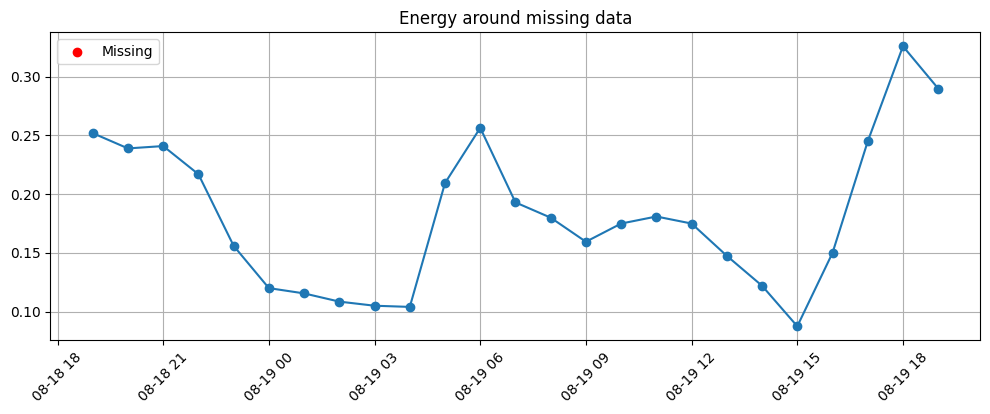

In [16]:
start = "2025-08-18 19:00:00"
end   = "2025-08-19 19:00:00"

full_range = pd.date_range(start=start, end=end, freq="h")
df_zoom = df.reindex(full_range)
df_zoom.head(10)
import matplotlib.pyplot as plt



plt.figure(figsize=(12,4))
plt.plot(df_zoom.index, df_zoom["energy_hour"], marker="o")
plt.scatter(df_zoom.index[df_zoom["energy_hour"].isna()],
            [0]*df_zoom["energy_hour"].isna().sum(),
            color="red", label="Missing")
plt.legend()
plt.title("Energy around missing data")
plt.xticks(rotation=45)
plt.grid()
plt.show()


In [17]:
df = df.sort_index()
df = df.asfreq('h')
full_range = pd.date_range(start=df.index.min(),
                           end=df.index.max(),
                           freq="H")

missing_time = full_range.difference(df.index)
print("Jumlah jam hilang:", len(missing_time))
print(missing_time)

Jumlah jam hilang: 0
DatetimeIndex([], dtype='datetime64[ns]', freq='h')


C:\Users\hakimfrh\AppData\Local\Temp\ipykernel_20148\1531309851.py:3: FutureWarning: 'H' is deprecated and will be removed in a future version, please use 'h' instead.
  full_range = pd.date_range(start=df.index.min(),


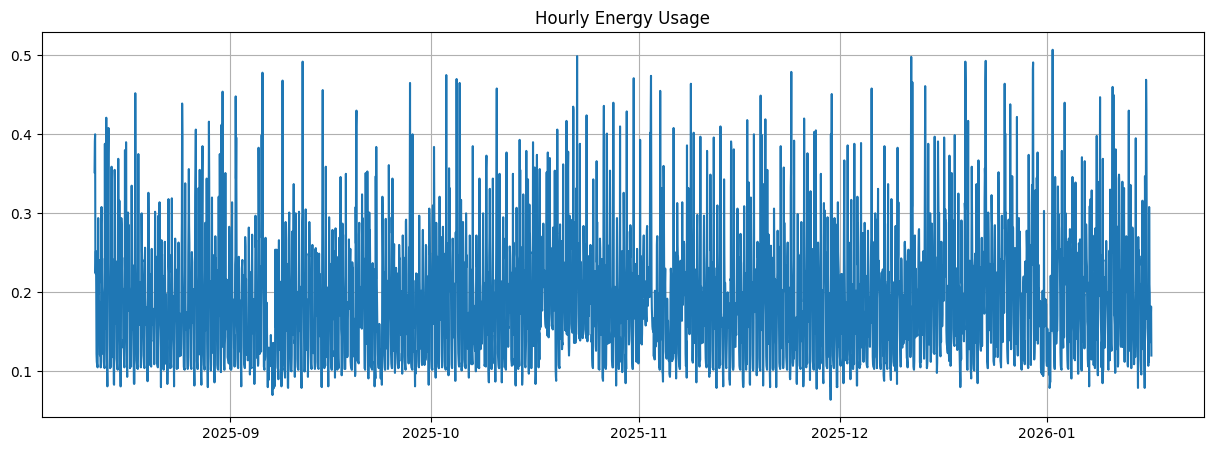

In [18]:
plt.figure(figsize=(15,5))
plt.plot(df.index, df['energy_hour'])
plt.title("Hourly Energy Usage")
plt.grid()
plt.show()


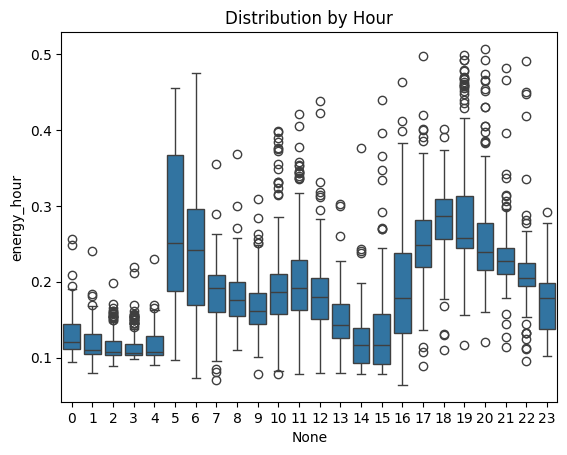

In [19]:
sns.boxplot(x=df.index.hour, y=df['energy_hour'])
plt.title("Distribution by Hour")
plt.show()


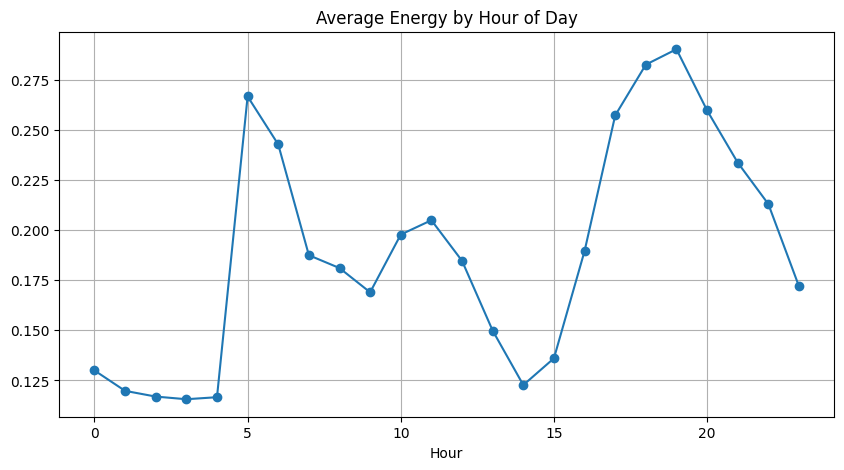

In [20]:
hour_avg = df.groupby(df.index.hour)['energy_hour'].mean()

plt.figure(figsize=(10,5))
plt.plot(hour_avg.index, hour_avg.values, marker='o')
plt.title("Average Energy by Hour of Day")
plt.xlabel("Hour")
plt.grid()
plt.show()


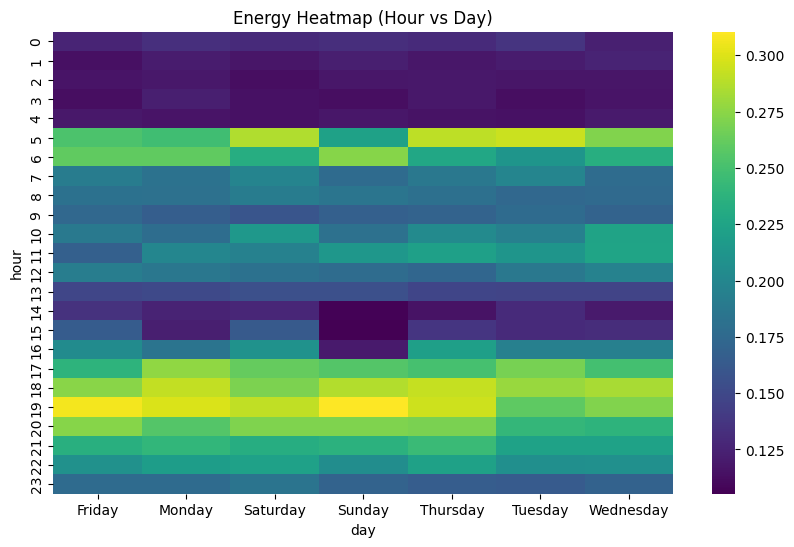

In [21]:
pivot = df.copy()
pivot['hour'] = pivot.index.hour
pivot['day'] = pivot.index.day_name()

heat = pivot.pivot_table(values='energy_hour', index='hour', columns='day', aggfunc='mean')

plt.figure(figsize=(10,6))
sns.heatmap(heat, cmap='viridis')
plt.title("Energy Heatmap (Hour vs Day)")
plt.show()


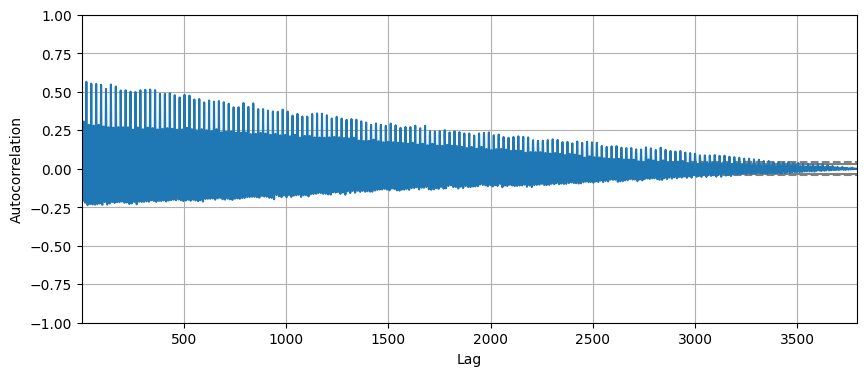

In [22]:
plt.figure(figsize=(10,4))
autocorrelation_plot(df['energy_hour'])
plt.show()


In [23]:
df['hour'] = df.index.hour
df['hour_sin'] = np.sin(2*np.pi*df.index.hour/24)
df['hour_cos'] = np.cos(2*np.pi*df.index.hour/24)

df['dayofweek'] = df.index.dayofweek
df['day_sin'] = np.sin(2*np.pi*df.index.dayofweek/7)
df['day_cos'] = np.cos(2*np.pi*df.index.dayofweek/7)


# df['lag_1'] = df['energy_hour'].shift(1)
# df['lag_24'] = df['energy_hour'].shift(24)
df['lag_168'] = df['energy_hour'].shift(168)  # minggu lalu jam sama

# df['diff1'] = df['energy_hour'].diff()
# df['diff24'] = df['energy_hour'].diff(24)

# df['roll_mean_3'] = df['energy_hour'].rolling(3).mean()
# df['roll_mean_6'] = df['energy_hour'].rolling(6).mean()
# df['roll_std_6']  = df['energy_hour'].rolling(6).std()

df = df.dropna()

array([<Axes: >, <Axes: >, <Axes: >, <Axes: >, <Axes: >, <Axes: >,
       <Axes: >, <Axes: >], dtype=object)

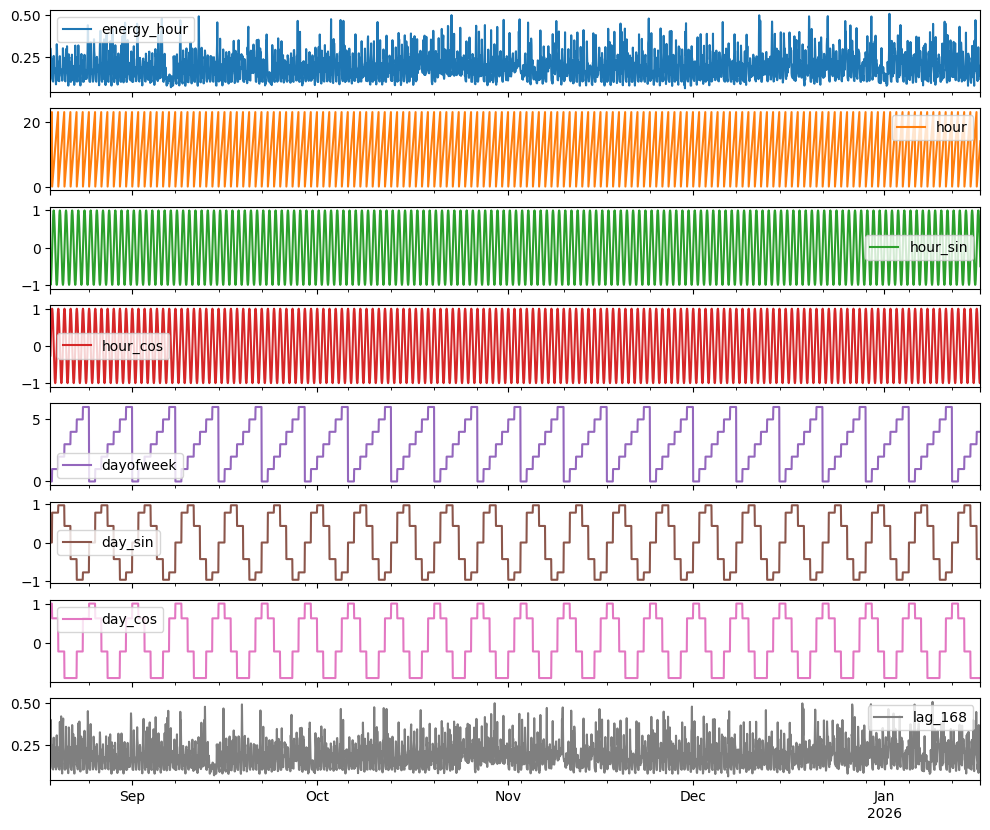

In [24]:
df.plot(subplots=True, figsize=(12,10))

In [25]:
scaler = MinMaxScaler()
df_scaled = scaler.fit_transform(df)

In [26]:
def create_dataset(data, window=72, forecast=24):
    X, y = [], []
    for i in range(len(data) - window - forecast + 1):
        X.append(data[i:i+window, :])   # all features
        y.append(data[i+window:i+window+forecast, 0])     # target next 24 hours
    return np.array(X), np.array(y)

# 3 days lookback (72 hours) -> predict next 24 hours
window_size = 72
forecast_size = 24
X, y = create_dataset(df_scaled, window_size, forecast_size)

print(X.shape)
print(y.shape)


(3527, 72, 8)
(3527, 24)


In [27]:
split = int(len(X)*0.8)

X_train, X_test = X[:split], X[split:]
y_train, y_test = y[:split], y[split:]

In [28]:
model = Sequential([
    LSTM(64, return_sequences=True, input_shape=(window_size, X.shape[2])),
    Dropout(0.2),
    LSTM(32),
    Dense(16, activation='relu'),
    Dense(forecast_size, activation='relu')  # 24-hour horizon
])


C:\Users\hakimfrh\AppData\Roaming\Python\Python311\site-packages\keras\src\layers\rnn\rnn.py:199: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


In [29]:
model.compile(optimizer='adam', loss='huber')
model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ lstm (LSTM)                     │ (None, 72, 64)         │        18,688 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 72, 64)         │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm_1 (LSTM)                   │ (None, 32)             │        12,416 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 16)             │           528 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 24)             │           408 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 32,040 (125.16 KB)

 Trainable params: 32,040 (125.16 KB)

 Non-trainable params: 0 (0.00 B)

In [30]:


early_stop = EarlyStopping(patience=10, restore_best_weights=True)

history = model.fit(X_train, y_train,
          validation_data=(X_test, y_test),
          epochs=100,
          batch_size=16,
          callbacks=[early_stop])

Epoch 1/100
177/177 ━━━━━━━━━━━━━━━━━━━━ 6s 22ms/step - loss: 0.0212 - val_loss: 0.0229
Epoch 2/100
177/177 ━━━━━━━━━━━━━━━━━━━━ 4s 21ms/step - loss: 0.0195 - val_loss: 0.0220
Epoch 3/100
177/177 ━━━━━━━━━━━━━━━━━━━━ 4s 21ms/step - loss: 0.0179 - val_loss: 0.0202
Epoch 4/100
177/177 ━━━━━━━━━━━━━━━━━━━━ 4s 20ms/step - loss: 0.0158 - val_loss: 0.0195
Epoch 5/100
177/177 ━━━━━━━━━━━━━━━━━━━━ 4s 21ms/step - loss: 0.0147 - val_loss: 0.0191
Epoch 6/100
177/177 ━━━━━━━━━━━━━━━━━━━━ 4s 21ms/step - loss: 0.0145 - val_loss: 0.0189
Epoch 7/100
177/177 ━━━━━━━━━━━━━━━━━━━━ 4s 21ms/step - loss: 0.0142 - val_loss: 0.0188
Epoch 8/100
177/177 ━━━━━━━━━━━━━━━━━━━━ 4s 22ms/step - loss: 0.0140 - val_loss: 0.0182
Epoch 9/100
177/177 ━━━━━━━━━━━━━━━━━━━━ 4s 21ms/step - loss: 0.0138 - val_loss: 0.0184
Epoch 10/100
177/177 ━━━━━━━━━━━━━━━━━━━━ 4s 21ms/step - loss: 0.0137 - val_loss: 0.0185
Epoch 11/100
177/177 ━━━━━━━━━━━━━━━━━━━━ 4s 21ms/step - loss: 0.0136 - val_loss: 0.0187
Epoch 12/100
177/177 ━━━━━━━━━

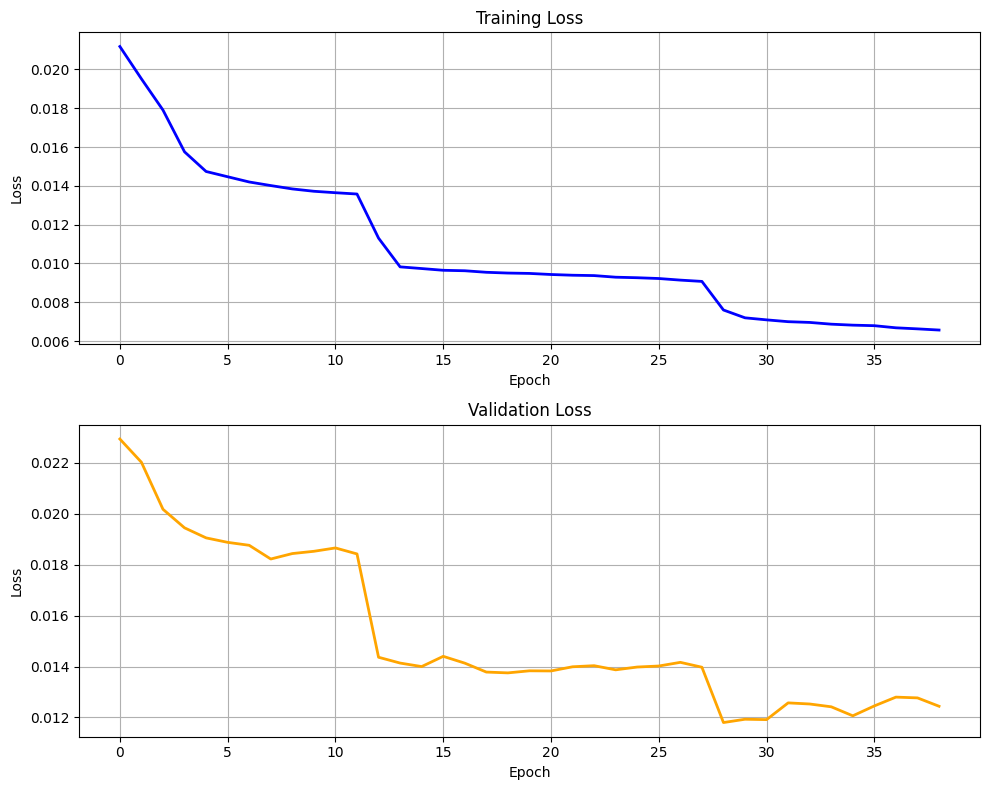

In [31]:
fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(10, 8))

# Grafik atas: Training Loss
ax1.plot(history.history['loss'], color='blue', linewidth=2)
ax1.set_xlabel('Epoch')
ax1.set_ylabel('Loss')
ax1.set_title('Training Loss')
ax1.grid(True)

# Grafik bawah: Validation Loss
ax2.plot(history.history['val_loss'], color='orange', linewidth=2)
ax2.set_xlabel('Epoch')
ax2.set_ylabel('Loss')
ax2.set_title('Validation Loss')
ax2.grid(True)

plt.tight_layout()
plt.show()

In [32]:
pred = model.predict(X_test)

23/23 ━━━━━━━━━━━━━━━━━━━━ 1s 17ms/step


In [33]:
pred_real = np.zeros_like(pred)
for i in range(pred.shape[1]):
    dummy = np.zeros((len(pred), df_scaled.shape[1]))
    dummy[:,0] = pred[:,i]
    pred_real[:,i] = scaler.inverse_transform(dummy)[:,0]


In [34]:
y_real = np.zeros_like(y_test)
for i in range(y_test.shape[1]):
    dummy2 = np.zeros((len(y_test), df_scaled.shape[1]))
    dummy2[:,0] = y_test[:,i]
    y_real[:,i] = scaler.inverse_transform(dummy2)[:,0]


RMSE: 0.06805514576188719
MAPE: 26.81835392555837 %
MAE: 0.04930595958304292


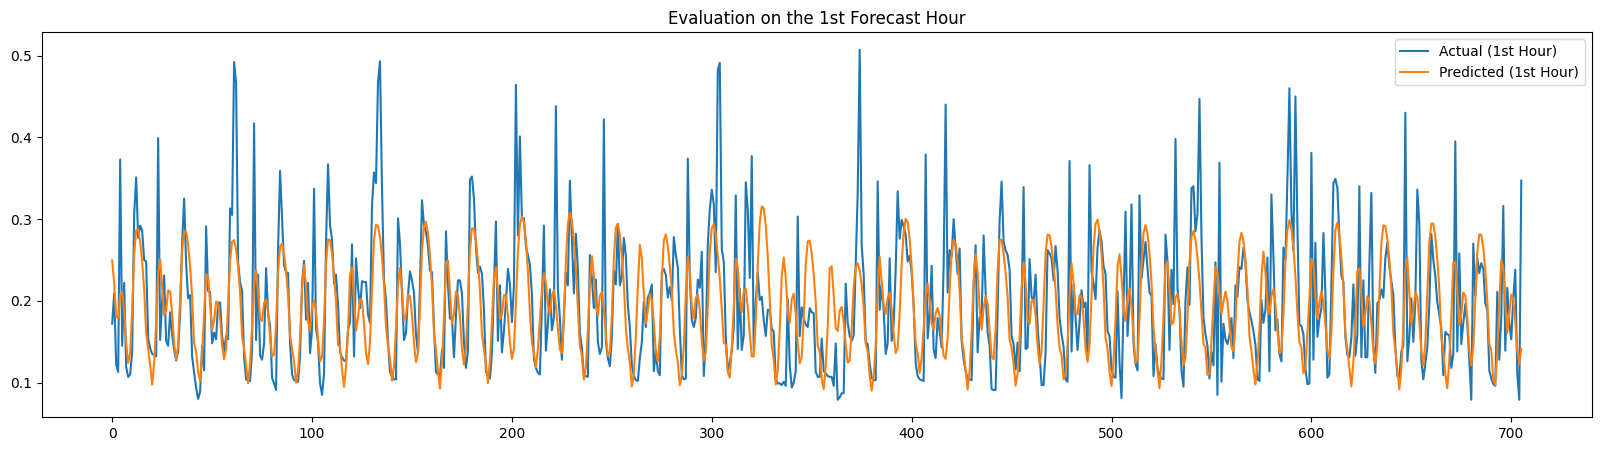

In [35]:
rmse = np.sqrt(mean_squared_error(y_real, pred_real))
mape = np.mean(np.abs((y_real - pred_real) / y_real)) * 100
mae = mean_absolute_error(y_real, pred_real)
print("RMSE:", rmse)
print("MAPE:", mape, "%")
print("MAE:", mae)

plt.figure(figsize=(20,5))
plt.plot(y_real[:,0], label="Actual (1st Hour)")
plt.plot(pred_real[:,0], label="Predicted (1st Hour)")
plt.title("Evaluation on the 1st Forecast Hour")
plt.legend()
plt.show()


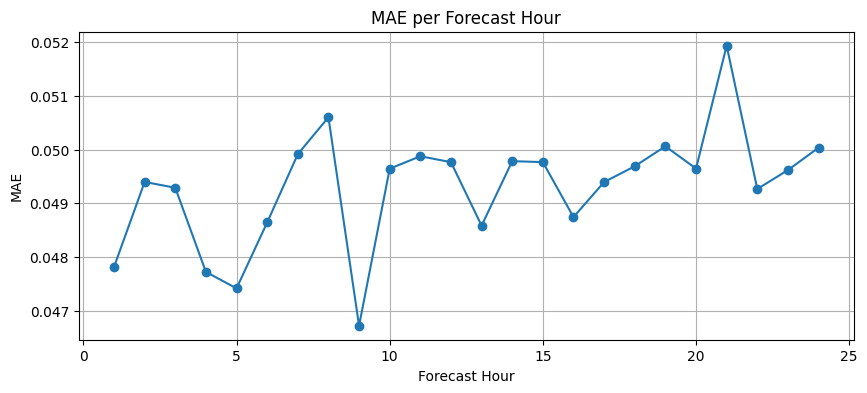

MAE Weekday: 0.05096848358758442
MAE Weekend: 0.04485524427921822
Best epoch: 29
Train loss at best epoch: 0.007601055316627026
Val loss at best epoch: 0.011800066567957401
Gap (val - train): 0.004199011251330376


In [36]:
# Analysis: MAE per horizon (1..24)
mae_per_h = np.mean(np.abs(y_real - pred_real), axis=0)
plt.figure(figsize=(10,4))
plt.plot(np.arange(1, forecast_size + 1), mae_per_h, marker='o')
plt.title("MAE per Forecast Hour")
plt.xlabel("Forecast Hour")
plt.ylabel("MAE")
plt.grid(True)
plt.show()

# Analysis: Weekday vs weekend MAE
base_times = df.index[window_size:window_size + len(y)]
test_base_times = base_times[split:]
time_grid = test_base_times.values[:, None] + np.arange(forecast_size).astype("timedelta64[h]")
flat_times = pd.to_datetime(time_grid.ravel())
flat_err = np.abs(y_real - pred_real).ravel()
weekend_mask = flat_times.dayofweek >= 5

mae_weekday = flat_err[~weekend_mask].mean()
mae_weekend = flat_err[weekend_mask].mean()
print("MAE Weekday:", mae_weekday)
print("MAE Weekend:", mae_weekend)

# Analysis: Train vs validation gap (overfitting check)
train_loss = np.array(history.history["loss"])
val_loss = np.array(history.history["val_loss"])
best_idx = int(np.argmin(val_loss))
print("Best epoch:", best_idx + 1)
print("Train loss at best epoch:", train_loss[best_idx])
print("Val loss at best epoch:", val_loss[best_idx])
print("Gap (val - train):", val_loss[best_idx] - train_loss[best_idx])


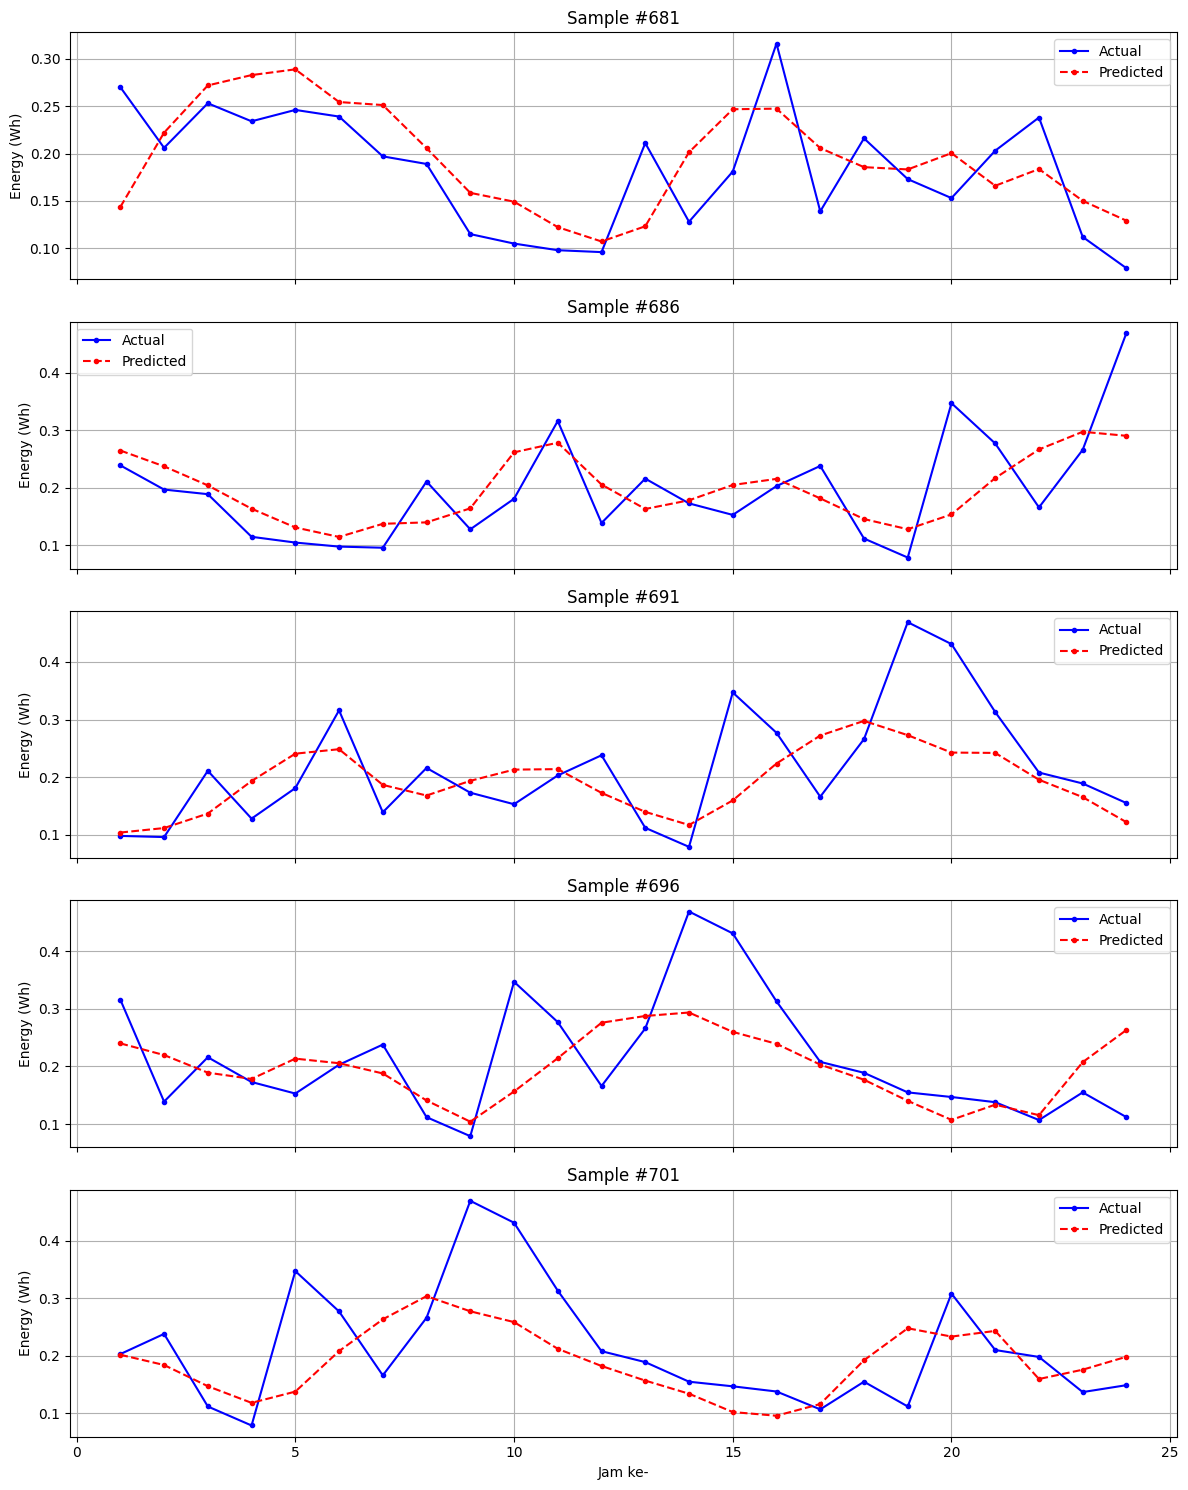

In [37]:
# === Plot contoh: ambil beberapa sample prediksi vs aktual ===

n_samples_show = 5
index = 1
fig, axes = plt.subplots(n_samples_show, 1, figsize=(12, 3*n_samples_show), sharex=True)
for i in range(n_samples_show):
    # idx = np.random.randint(0, len(y_real))
    idx = len(y_real) - (n_samples_show * 6) + (n_samples_show * index)
    index += 1
    axes[i].plot(range(1, forecast_size + 1), y_real[idx], 'b.-', label='Actual')
    axes[i].plot(range(1, forecast_size + 1), pred_real[idx], 'r.--', label='Predicted')
    axes[i].set_ylabel("Energy (Wh)")
    axes[i].set_title(f"Sample #{idx}")
    axes[i].legend()
    axes[i].grid(True)
axes[-1].set_xlabel("Jam ke-")
plt.tight_layout()
plt.show()


In [38]:
# Take the last 3 days window from scaled data
window = df_scaled[-window_size:].copy()

# Predict the next 24 hours directly
pred_scaled = model.predict(window[np.newaxis, :, :], verbose=0)[0]


In [39]:
dummy = np.zeros((forecast_size, df_scaled.shape[1]))
dummy[:,0] = pred_scaled

predictions_real = scaler.inverse_transform(dummy)[:,0]


In [40]:
future_index = pd.date_range(
    start=df.index[-1] + pd.Timedelta(hours=1),
    periods=forecast_size,
    freq="H"
)


C:\Users\hakimfrh\AppData\Local\Temp\ipykernel_20148\4029140890.py:1: FutureWarning: 'H' is deprecated and will be removed in a future version, please use 'h' instead.
  future_index = pd.date_range(


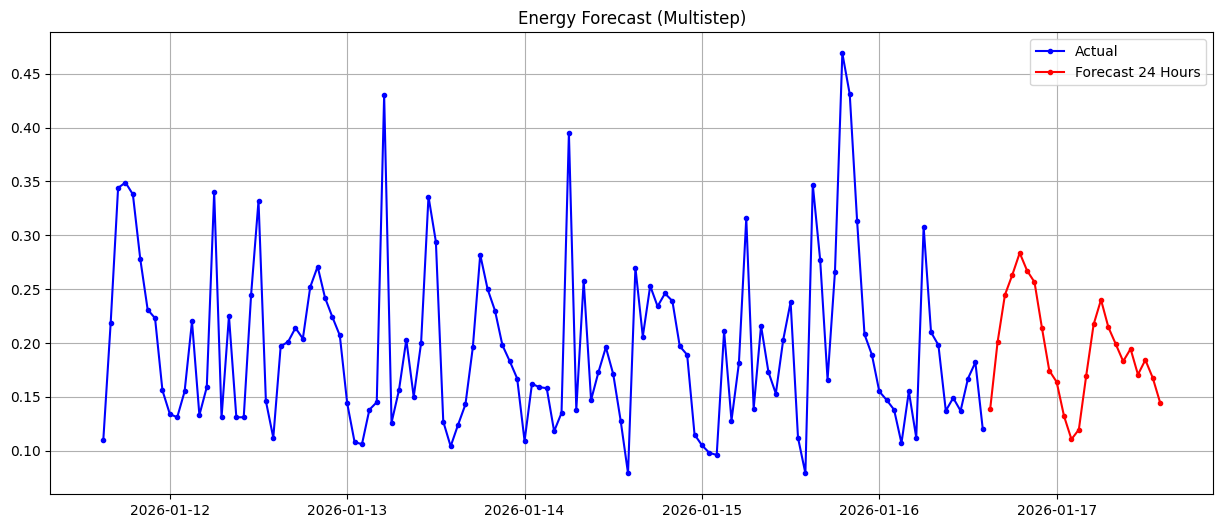

In [41]:
plt.figure(figsize=(15,6))

# data asli 5 hari terakhir
plt.plot(df.index[-24*5:], df['energy_hour'][-24*5:], 'b.-', label='Actual')

# prediksi 24 jam ke depan
plt.plot(future_index, predictions_real, 'r.-', label='Forecast 24 Hours')

plt.title("Energy Forecast (Multistep)")
plt.legend()
plt.grid()
plt.show()


In [ ]:
# Save trained model
# Model save name (without extension)
# model_name = "siwatt_lstm_hour_v2.2"

# model.save(f"{model_name}.keras")
# print(f"Saved model to {model_name}.keras")


Saved model to siwatt_lstm_hour_v2.2.keras
